In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('Advertising.csv')
print("Libraries imported successfully.")



Libraries imported successfully.


In [55]:
X=df.drop('sales',axis=1)
y=df['sales']


In [56]:
from sklearn.preprocessing import PolynomialFeatures



In [57]:
polynomial_converter = PolynomialFeatures(degree=2, include_bias=False)
polynomial_converter.fit(X)
poly_feature=polynomial_converter.transform(X)
poly_feature.shape

(200, 9)

In [58]:
X.iloc[0]

TV           230.1
radio         37.8
newspaper     69.2
Name: 0, dtype: float64

In [59]:
poly_feature[0]

array([2.301000e+02, 3.780000e+01, 6.920000e+01, 5.294601e+04,
       8.697780e+03, 1.592292e+04, 1.428840e+03, 2.615760e+03,
       4.788640e+03])

In [60]:
37.8*69.2

2615.7599999999998

In [61]:
polynomial_converter.fit_transform(X)

array([[ 230.1 ,   37.8 ,   69.2 , ..., 1428.84, 2615.76, 4788.64],
       [  44.5 ,   39.3 ,   45.1 , ..., 1544.49, 1772.43, 2034.01],
       [  17.2 ,   45.9 ,   69.3 , ..., 2106.81, 3180.87, 4802.49],
       ...,
       [ 177.  ,    9.3 ,    6.4 , ...,   86.49,   59.52,   40.96],
       [ 283.6 ,   42.  ,   66.2 , ..., 1764.  , 2780.4 , 4382.44],
       [ 232.1 ,    8.6 ,    8.7 , ...,   73.96,   74.82,   75.69]],
      shape=(200, 9))

Train and Evaluating Polynomial 

In [62]:
#TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(poly_feature,y,test_size=0.3,random_state=101)


In [63]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [64]:
test_predictions = model.predict(X_test)

In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

MAE = mean_absolute_error(y_test, test_predictions)
MSE = mean_squared_error(y_test, test_predictions)
RMSE = np.sqrt(MSE)
print("MAE:", MAE)
print("MSE:", MSE)
print("RMSE:", RMSE)

MAE: 0.5276953770204031
MSE: 0.64995105805254
RMSE: 0.8061954217511658


In [66]:
# MODEL COEFFICIENTS
model.coef_

array([ 5.17095811e-02,  1.30848864e-02,  1.20000085e-02, -1.10892474e-04,
        1.14212673e-03, -5.24100082e-05,  3.34919737e-05,  1.46380310e-04,
       -3.04715806e-05])

In [67]:
poly_feature[0]

array([2.301000e+02, 3.780000e+01, 6.920000e+01, 5.294601e+04,
       8.697780e+03, 1.592292e+04, 1.428840e+03, 2.615760e+03,
       4.788640e+03])

In [68]:
    X.iloc[0]

TV           230.1
radio         37.8
newspaper     69.2
Name: 0, dtype: float64

In [69]:
69.2**2

4788.64

Chossing Degree OF Polynominal

1.Create the different order poly 

2.Split poly feat train/test 

3.fit on train

4.Store/save the rmse for both the train and test
 
5.plot the results (error vs poly order)

([<matplotlib.axis.XTick at 0x206bf1a7750>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9')])

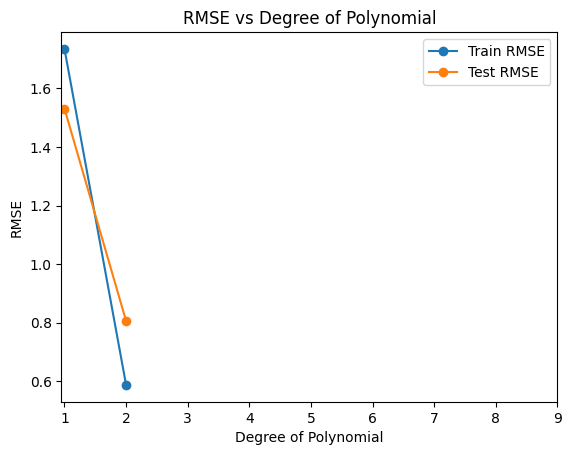

In [70]:
train_rmse_errors = []
test_rmse_errors = []

for d in range(1, 10):
    polynomial_converter = PolynomialFeatures(degree=d, include_bias=False)
    poly_features = polynomial_converter.fit_transform(X)
    
    X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
    
    train_rmse_errors.append(train_rmse)
    test_rmse_errors.append(test_rmse)
# plt.figure(figsize=(10, 6))
plt.plot(range(1, 3), train_rmse_errors[:2], label='Train RMSE', marker='o')
plt.plot(range(1, 3), test_rmse_errors[:2], label='Test RMSE', marker='o')
plt.xlabel('Degree of Polynomial')  
plt.ylabel('RMSE')
plt.title('RMSE vs Degree of Polynomial')
plt.legend()
plt.xticks(range(1, 10))

In [71]:
test_rmse_errors

[np.float64(1.5307856371504507),
 np.float64(0.8061954217511658),
 np.float64(0.840535905144508),
 np.float64(0.8374357267109016),
 np.float64(2.6766070532332),
 np.float64(9.888340814281609),
 np.float64(41.33391086389979),
 np.float64(3108.59080645116),
 np.float64(12767.649356686912)]

In [72]:
train_rmse_errors

[np.float64(1.734594124329376),
 np.float64(0.5879574085292234),
 np.float64(0.43393443569020657),
 np.float64(0.35170836883993556),
 np.float64(0.2509342923820358),
 np.float64(0.20953728417844544),
 np.float64(0.22046859203477034),
 np.float64(0.2715007492459394),
 np.float64(0.5132041534764287)]

Model Deployement

In [73]:
final_poly_converter = PolynomialFeatures(degree=3, include_bias=False)
final_model = LinearRegression()
final_poly_features= final_poly_converter.fit_transform(X)
final_model.fit(final_poly_features,X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [74]:
from joblib import dump,load
dump(final_model,'final_poly_model.joblib')


['final_poly_model.joblib']

In [75]:
dump(final_poly_converter,'final_poly_converter.joblib')

['final_poly_converter.joblib']

In [78]:
loaded_poly_converter = load('final_poly_converter.joblib')
loaded_model = load('final_poly_model.joblib')


In [81]:

campaign = np.array([[149, 22, 12]])
transformed_data = loaded_poly_converter.fit_transform(campaign)
loaded_model.predict(transformed_data)



array([[149.,  22.,  12.]])